# 08 · Distributed Inference and Information Fusion
**Companion to the lecture:** *Distributed Inference and Information Fusion* — Pramod Varshney.

> ⚠️ The slides for this lecture are **not** in the PDF. This notebook is based on the canonical distributed-detection 
> literature (Varshney, *Distributed Detection and Data Fusion*, 1997).

In **distributed** detection, each sensor makes a local decision (a bit) and sends it to a fusion center instead of the 
raw data — saving bandwidth. The questions: which **fusion rule** at the center? and how are the local **thresholds** set?

## A. The ROC curve and the detection/false-alarm trade-off
Each sensor is characterized by $(P_D, P_{FA})$. For detecting a signal $A$ in Gaussian noise $\sigma$ with threshold $\tau$:
$$P_{FA}=Q(\tau/\sigma), \qquad P_D=Q((\tau-A)/\sigma), \qquad Q(x)=\tfrac12\operatorname{erfc}(x/\sqrt2)$$
The SNR determines the ROC curve — the 'higher' it is (closer to the top-left corner), the better the detection.

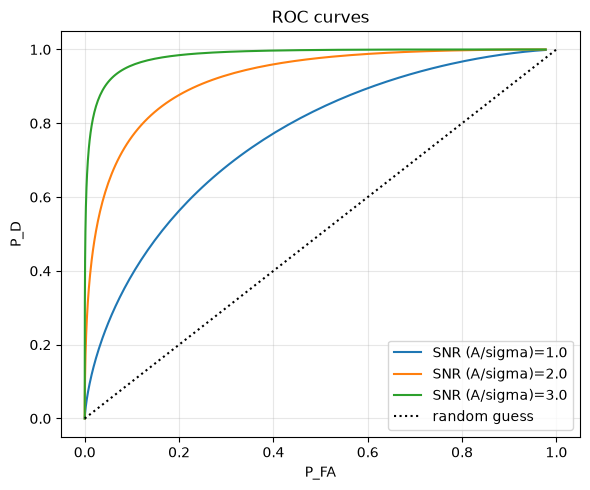

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erfc, sqrt
rng = np.random.default_rng(2)
Q = lambda x: 0.5*erfc(x/sqrt(2))
Qv = np.vectorize(Q)

taus = np.linspace(-2,8,300)
plt.figure(figsize=(6,5))
for A in [1.0, 2.0, 3.0]:
    pfa=Qv(taus); pd=Qv(taus-A)
    plt.plot(pfa,pd,label=f'SNR (A/sigma)={A}')
plt.plot([0,1],[0,1],'k:',label='random guess')
plt.xlabel('P_FA'); plt.ylabel('P_D'); plt.title('ROC curves'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## B. Decision fusion rules: AND / OR / majority (k-out-of-N)
With $N$ conditionally independent sensors, the fusion center declares H1 if at least $k$ sensors reported '1':
* **OR** ($k=1$) — very sensitive, high $P_D$ but also high $P_{FA}$.
* **AND** ($k=N$) — conservative, low $P_{FA}$ but low $P_D$.
* **Majority** ($k=\lceil N/2\rceil$) — a balance.
$$P_D^{fus}=\sum_{i=k}^{N}\binom{N}{i}P_D^i(1-P_D)^{N-i}$$

single sensor: P_D=0.6, P_FA=0.1
OR (1/5)          P_D=0.990  P_FA=0.4095
majority (3/5)    P_D=0.683  P_FA=0.0086
AND (5/5)         P_D=0.078  P_FA=0.0000


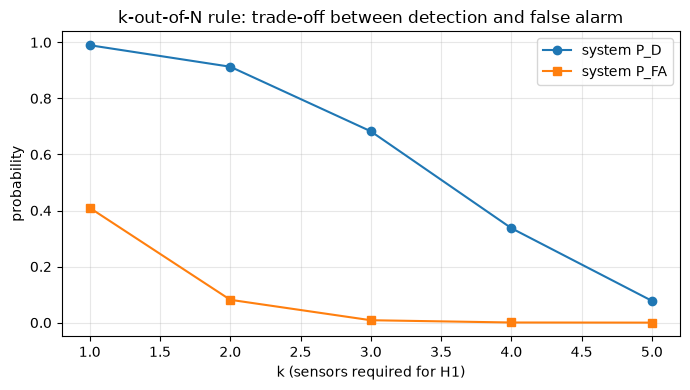

In [2]:
from math import comb
def kN(p, N, k): return sum(comb(N,i)*p**i*(1-p)**(N-i) for i in range(k,N+1))
N=5; pd, pfa = 0.6, 0.1
print(f'single sensor: P_D={pd}, P_FA={pfa}')
for name,k in [('OR (1/5)',1),('majority (3/5)',3),('AND (5/5)',5)]:
    print(f'{name:16s}  P_D={kN(pd,N,k):.3f}  P_FA={kN(pfa,N,k):.4f}')

ks=range(1,N+1)
plt.figure(figsize=(7,4))
plt.plot(list(ks),[kN(pd,N,k) for k in ks],'o-',label='system P_D')
plt.plot(list(ks),[kN(pfa,N,k) for k in ks],'s-',label='system P_FA')
plt.xlabel('k (sensors required for H1)'); plt.ylabel('probability')
plt.title('k-out-of-N rule: trade-off between detection and false alarm'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## C. The optimal Chair–Varshney fusion rule
When each sensor's $(P_{D,i},P_{FA,i})$ are known, the optimal LRT fusion rule weights each local decision 
$u_i\in\{0,1\}$ by its **reliability**:
$$\sum_i \Big[u_i\ln\tfrac{P_{D,i}}{P_{FA,i}} + (1-u_i)\ln\tfrac{1-P_{D,i}}{1-P_{FA,i}}\Big] \;\gtrless\; \ln\tfrac{P_0}{P_1}$$
More reliable sensors receive larger weight — unlike an 'equal' majority vote.

In [3]:
def chair_varshney(u, PD, PFA, P1=0.5):
    P0=1-P1; s=0.0
    for ui,pd,pf in zip(u,PD,PFA):
        s += np.log(pd/pf) if ui==1 else np.log((1-pd)/(1-pf))
    return 1 if s >= np.log(P0/P1) else 0

# 5 heterogeneous sensors: some reliable, some noisy
PD =np.array([0.95,0.9,0.6,0.55,0.7])
PFA=np.array([0.02,0.05,0.3,0.4,0.2])
def majority(u): return 1 if sum(u)>=3 else 0

trials=20000; H1prob=0.5; cv_ok=maj_ok=0
for _ in range(trials):
    H=int(rng.random()<H1prob)
    u=[int(rng.random()<(PD[i] if H else PFA[i])) for i in range(5)]
    cv_ok += chair_varshney(u,PD,PFA)==H
    maj_ok+= majority(u)==H
print(f'majority-vote accuracy   : {maj_ok/trials:.1%}')
print(f'Chair-Varshney accuracy  : {cv_ok/trials:.1%}  (weights reliability -> better with heterogeneous sensors)')

majority-vote accuracy   : 93.5%
Chair-Varshney accuracy  : 97.8%  (weights reliability -> better with heterogeneous sensors)


## D. Broader context: consensus and confidence
* **Consensus / gossip** — nodes in a network without a center converge to a global estimate through local exchanges only.
* **Quantization** — sending a few bits instead of full values; a bandwidth-vs-accuracy trade-off.
* **Unreliable communication** — message loss/delay requires robust fusion.
All of these are distributed generalizations of the same principle: **accumulating information reduces uncertainty** (the fusion equation, notebook 01).

## Summary
* **ROC** characterizes each sensor; the SNR sets the performance limit.
* **k-out-of-N** rules (OR/majority/AND) give different trade-offs between $P_D$ and $P_{FA}$.
* **Chair–Varshney** is the optimal fusion rule — weighting by reliability, superior to majority voting when sensors are heterogeneous.